# Cybersecurity and National Defence Ex. 5
## Practical Exercise: NVD API, Pandas, and Matplotlib

In this notebook, we will implement the practical components of Lab 5. Ensure your virtual environment is active and libraries (`requests`, `pandas`, `matplotlib`) are installed.

In [1]:
import requests
import json

base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
params = {
    "keywordSearch": "Microsoft Windows",
    "resultsPerPage": 2000,
    "startIndex": 0,
    "pubStartDate": "2018-01-01T00:00:00.000Z",
    "pubEndDate": "2018-04-30T00:00:00.000Z"
}

print("Querying the NVD API (this may take a few seconds)...")
response = requests.get(base_url, params=params)

if response.status_code == 200:
    data = response.json()
    with open("cve_data.json", "w") as f:
        json.dump(data, f, indent=4)
        
    total_results = data.get("totalResults", 0)
    print(f"Success! Saved data. The NVD database returned {total_results} total matching CVEs, and we downloaded {len(data.get('vulnerabilities', []))}.")
else:
    print(f"Error {response.status_code}: Failed to retrieve data.\n{response.text}")

Querying the NVD API (this may take a few seconds)...
Success! Saved data. The NVD database returned 90 total matching CVEs, and we downloaded 90.


### Data Analysis with Pandas
Now that we have saved the API response locally, we will parse the nested JSON and extract the key variables into a Pandas DataFrame.

In [2]:
import pandas as pd
import json

with open("cve_data.json", "r") as f:
    raw_data = json.load(f)

vulnerabilities = raw_data.get("vulnerabilities", [])

parsed_cves = []
for item in vulnerabilities:
    cve_details = item.get("cve", {})
    
    cve_id = cve_details.get("id", "Unknown")
    vuln_status = cve_details.get("vulnStatus", "Unknown")
    published_date = cve_details.get("published", None)
    
    descriptions = cve_details.get("descriptions", [])
    desc_text = "No description available"
    for d in descriptions:
        if d.get("lang") == "en":
            desc_text = d.get("value", "No description available")
            break
            
    vuln_type = "Unknown"
    weaknesses = cve_details.get("weaknesses", [])
    if weaknesses:
        for w in weaknesses:
            desc_list = w.get("description", [])
            for d in desc_list:
                if d.get("lang") == "en":
                    vuln_type = d.get("value", "Unknown")
                    break
            if vuln_type != "Unknown":
                break
                
    metrics = cve_details.get("metrics", {})
    
    score = None
    severity = "NONE"
    
    if "cvssMetricV31" in metrics:
        score = metrics["cvssMetricV31"][0].get("cvssData", {}).get("baseScore")
        severity = metrics["cvssMetricV31"][0].get("cvssData", {}).get("baseSeverity", "NONE")
    elif "cvssMetricV30" in metrics:
        score = metrics["cvssMetricV30"][0].get("cvssData", {}).get("baseScore")
        severity = metrics["cvssMetricV30"][0].get("cvssData", {}).get("baseSeverity", "NONE")
    elif "cvssMetricV2" in metrics:
        score = metrics["cvssMetricV2"][0].get("cvssData", {}).get("baseScore")
        severity = metrics["cvssMetricV2"][0].get("baseSeverity", "NONE")
        
    parsed_cves.append({
        "CVE_ID": cve_id,
        "Status": vuln_status,
        "Vulnerability_Type": vuln_type,
        "Published_Date": published_date,
        "CVSS_Score": score,
        "Severity": severity,
        "Description": desc_text
    })

df = pd.DataFrame(parsed_cves)
df['Published_Date'] = pd.to_datetime(df['Published_Date'])

print(f"Total CVEs successfully loaded into Pandas DataFrame: {len(df)}")
print("Previewing First 5 Rows using df.head():")
df.drop(columns=['Description']).head()

Total CVEs successfully loaded into Pandas DataFrame: 90
Previewing First 5 Rows using df.head():


,CVE_ID,Status,Vulnerability_Type,Published_Date,CVSS_Score,Severity
0,CVE-2018-0749,Modified,NVD-CWE-noinfo,2018-01-04 14:29:00.533,7.8,HIGH
1,CVE-2018-0758,Modified,CWE-787,2018-01-04 14:29:00.767,7.5,HIGH
2,CVE-2018-0762,Modified,CWE-787,2018-01-04 14:29:00.817,7.5,HIGH
3,CVE-2018-0766,Modified,CWE-200,2018-01-04 14:29:00.847,4.3,MEDIUM
4,CVE-2018-0767,Modified,CWE-125,2018-01-04 14:29:00.893,5.3,MEDIUM


### Typical Pandas Operations

Once the data is in a DataFrame, we can easily sort, group, and analyze it. For instance:
1. **Finding the Worst Incident**: We can sequence the DataFrame by `CVSS_Score` to locate the most destructive vulnerabilities.
2. **Examining the Most Common Attack Vector**: We can filter out the most frequently occurring `Vulnerability_Type` (CWE) and read an example.

In [3]:
print("--- Status Distribution ---")
print(df['Status'].value_counts())

print("\n--- Worst Vulnerability Found ---")
if not df['CVSS_Score'].isna().all():
    worst_cve = df.loc[df['CVSS_Score'].idxmax()]
    print(f"CVE ID: {worst_cve['CVE_ID']}")
    print(f"Severity: {worst_cve['Severity']} ({worst_cve['CVSS_Score']} / 10.0)")
    print(f"Published: {worst_cve['Published_Date']}")
    print(f"Description:\n{worst_cve['Description']}")
else:
    print("No CVSS scores available in this dataset to compare.")

print("\n--- Recent Vulnerabilities ---")
recent_cves = df.sort_values(by='Published_Date', ascending=False).head(3)
print(recent_cves[['CVE_ID', 'Published_Date', 'CVSS_Score', 'Severity']])

--- Status Distribution ---
Status
Modified    90
Name: count, dtype: int64

--- Worst Vulnerability Found ---
CVE ID: CVE-2018-5440
Severity: CRITICAL (9.8 / 10.0)
Published: 2018-02-15 10:29:00.680000
Description:
A Stack-based Buffer Overflow issue was discovered in 3S-Smart CODESYS Web Server. Specifically: all Microsoft Windows (also WinCE) based CODESYS web servers running stand-alone Version 2.3, or as part of the CODESYS runtime system running prior to Version V1.1.9.19. A crafted request may cause a buffer overflow and could therefore execute arbitrary code on the web server or lead to a denial-of-service condition due to a crash in the web server.

--- Recent Vulnerabilities ---
           CVE_ID          Published_Date  CVSS_Score Severity
89  CVE-2018-1003 2018-04-12 01:29:09.113         7.8     HIGH
88  CVE-2018-0986 2018-04-04 17:29:01.583         8.8     HIGH
87  CVE-2017-4028 2018-04-03 22:29:00.523         5.0   MEDIUM


**Deep Dive: Most Common CWE**
Let's identify the most frequent vulnerability type in our dataset and print a concrete example of it.

In [4]:
print("--- Examining the Most Common Vulnerability Type ---")

# Filter to known CWEs
common_cwes = df[~df['Vulnerability_Type'].isin(['Unknown', 'NVD-CWE-noinfo', 'NVD-CWE-Other'])]

if not common_cwes.empty:
    top_cwe = common_cwes['Vulnerability_Type'].value_counts().idxmax()
    top_cwe_count = common_cwes['Vulnerability_Type'].value_counts().max()
    
    print(f"The most common identifier is {top_cwe} with {top_cwe_count} incidents in this dataset.")
    
    # Get an example of this specific CWE (Highest severity one)
    example_cve = df[df['Vulnerability_Type'] == top_cwe].sort_values(by='CVSS_Score', ascending=False).iloc[0]
    
    print("\n--- Example Incident for this Attack Vector ---")
    print(f"CVE ID: {example_cve['CVE_ID']}")
    print(f"Severity: {example_cve['Severity']} ({example_cve['CVSS_Score']})")
    print(f"Description:\n{example_cve['Description']}")
else:
    print("No specific CWE data found.")

--- Examining the Most Common Vulnerability Type ---
The most common identifier is CWE-787 with 39 incidents in this dataset.

--- Example Incident for this Attack Vector ---
CVE ID: CVE-2018-0986
Severity: HIGH (8.8)
Description:
A remote code execution vulnerability exists when the Microsoft Malware Protection Engine does not properly scan a specially crafted file, leading to memory corruption, aka "Microsoft Malware Protection Engine Remote Code Execution Vulnerability." This affects Windows Defender, Windows Intune Endpoint Protection, Microsoft Security Essentials, Microsoft System Center Endpoint Protection, Microsoft Exchange Server, Microsoft System Center, Microsoft Forefront Endpoint Protection.


### Data Visualization with Matplotlib & Pandas
We can use Pandas plotted wrappers around Matplotlib to quickly generate compelling imagery.

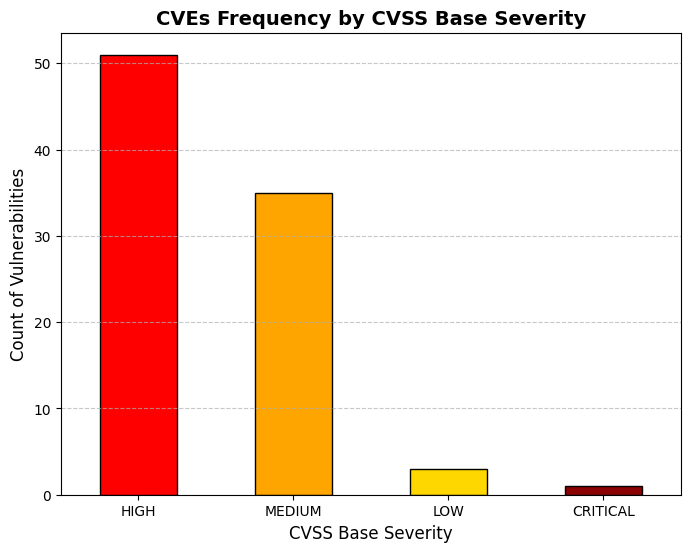

In [5]:
import matplotlib.pyplot as plt

# 1. Histogram / Bar chart of Severity classifications
filtered_df = df[df['Severity'] != "NONE"]
severity_counts = filtered_df['Severity'].value_counts()

plt.figure(figsize=(8, 6))
color_map = {'CRITICAL': 'darkred', 'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'gold'}
bar_colors = [color_map.get(x, 'gray') for x in severity_counts.index]

severity_counts.plot(kind='bar', color=bar_colors, edgecolor='black')
plt.title('CVEs Frequency by CVSS Base Severity', fontsize=14, fontweight='bold')
plt.xlabel('CVSS Base Severity', fontsize=12)
plt.ylabel('Count of Vulnerabilities', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Categorization: Most Frequent Vulnerability Types**
The Common Weakness Enumeration (CWE) dictates exactly what kind of attack vector the vulnerability opened.

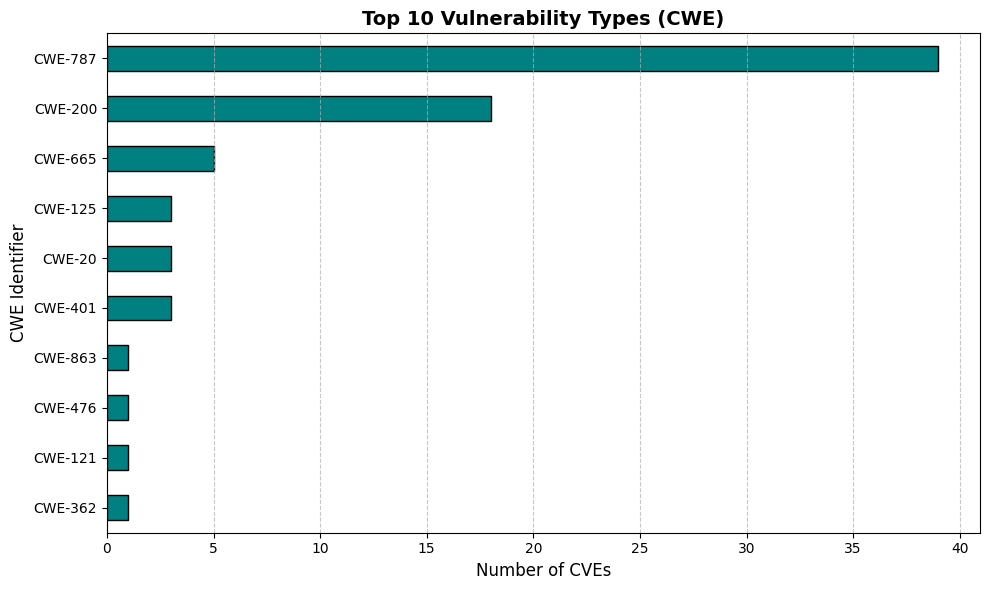

In [6]:
types_df = df[~df['Vulnerability_Type'].isin(['Unknown', 'NVD-CWE-noinfo'])]
type_counts = types_df['Vulnerability_Type'].value_counts().head(10)

plt.figure(figsize=(10, 6))
type_counts.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Vulnerability Types (CWE)', fontsize=14, fontweight='bold')
plt.xlabel('Number of CVEs', fontsize=12)
plt.ylabel('CWE Identifier', fontsize=12)
plt.gca().invert_yaxis() # Display the highest counts at the top of the chart
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('cve_types_chart.png')
plt.show()

**Scatter Plot of Discoveries over Time**
Plotting each vulnerability as a point across a chronological axis easily visualizes when severity spikes occurred.

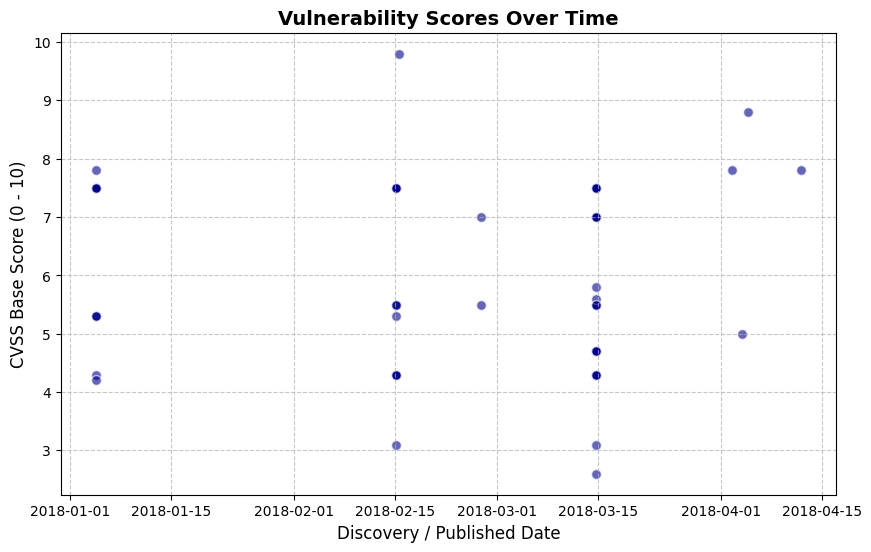

In [7]:
scatter_df = df.dropna(subset=['Published_Date', 'CVSS_Score'])

if not scatter_df.empty:
    ax = scatter_df.plot(
        kind='scatter', 
        x='Published_Date', 
        y='CVSS_Score', 
        alpha=0.6, 
        color='darkblue', 
        figsize=(10, 6),
        edgecolors='w',
        s=50 # Point size
    )
    
    plt.title('Vulnerability Scores Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Discovery / Published Date', fontsize=12)
    plt.ylabel('CVSS Base Score (0 - 10)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Not enough data to plot.")

### Secondary Dataset Analysis
We will now pull a different dataset, using the keyword `"Linux Kernel"`, with the same amount of results (2000).
We'll then compare the original dataset (`Microsoft Windows`) with this new dataset using Pandas.

In [8]:
# import requests
# import json

base_url = "https://services.nvd.nist.gov/rest/json/cves/2.0"
params_linux = {
    "keywordSearch": "Linux Kernel",
    "resultsPerPage": 2000,
    "startIndex": 0,
}

print("Querying the NVD API for 'Linux Kernel' (this may take a few seconds)...")
response_linux = requests.get(base_url, params=params_linux)

if response_linux.status_code == 200:
    data_linux = response_linux.json()
    with open("cve_data_linux.json", "w") as f:
        json.dump(data_linux, f, indent=4)
        
    total_results_linux = data_linux.get("totalResults", 0)
    print(f"Success! Saved data. The NVD database returned {total_results_linux} total matching CVEs, and we downloaded {len(data_linux.get('vulnerabilities', []))}.")
else:
    print(f"Error {response_linux.status_code}: Failed to retrieve data.\n{response_linux.text}")


Querying the NVD API for 'Linux Kernel' (this may take a few seconds)...
Success! Saved data. The NVD database returned 14399 total matching CVEs, and we downloaded 2000.


In [9]:
# Parse the new dataset into a Pandas DataFrame
with open("cve_data_linux.json", "r") as f:
    raw_data_linux = json.load(f)

vulnerabilities_linux = raw_data_linux.get("vulnerabilities", [])

parsed_cves_linux = []
for item in vulnerabilities_linux:
    cve_details = item.get("cve", {})
    
    cve_id = cve_details.get("id", "Unknown")
    vuln_status = cve_details.get("vulnStatus", "Unknown")
    published_date = cve_details.get("published", None)
    
    descriptions = cve_details.get("descriptions", [])
    desc_text = "No description available"
    for d in descriptions:
        if d.get("lang") == "en":
            desc_text = d.get("value", "No description available")
            break
            
    vuln_type = "Unknown"
    weaknesses = cve_details.get("weaknesses", [])
    if weaknesses:
        for w in weaknesses:
            desc_list = w.get("description", [])
            for d in desc_list:
                if d.get("lang") == "en":
                    vuln_type = d.get("value", "Unknown")
                    break
            if vuln_type != "Unknown":
                break
                
    metrics = cve_details.get("metrics", {})
    
    score = None
    severity = "NONE"
    
    if "cvssMetricV31" in metrics:
        score = metrics["cvssMetricV31"][0].get("cvssData", {}).get("baseScore")
        severity = metrics["cvssMetricV31"][0].get("cvssData", {}).get("baseSeverity", "NONE")
    elif "cvssMetricV30" in metrics:
        score = metrics["cvssMetricV30"][0].get("cvssData", {}).get("baseScore")
        severity = metrics["cvssMetricV30"][0].get("cvssData", {}).get("baseSeverity", "NONE")
    elif "cvssMetricV2" in metrics:
        score = metrics["cvssMetricV2"][0].get("cvssData", {}).get("baseScore")
        severity = metrics["cvssMetricV2"][0].get("baseSeverity", "NONE")
        
    parsed_cves_linux.append({
        "CVE_ID": cve_id,
        "Status": vuln_status,
        "Vulnerability_Type": vuln_type,
        "Published_Date": published_date,
        "CVSS_Score": score,
        "Severity": severity,
        "Description": desc_text
    })

df_linux = pd.DataFrame(parsed_cves_linux)
df_linux['Published_Date'] = pd.to_datetime(df_linux['Published_Date'])

print(f"Total Linux Kernel CVEs loaded into Pandas DataFrame: {len(df_linux)}")


Total Linux Kernel CVEs loaded into Pandas DataFrame: 2000


--- Average CVSS Score ---
Dataset
Linux Kernel    5.821711
Windows         6.343333
Name: CVSS_Score, dtype: float64


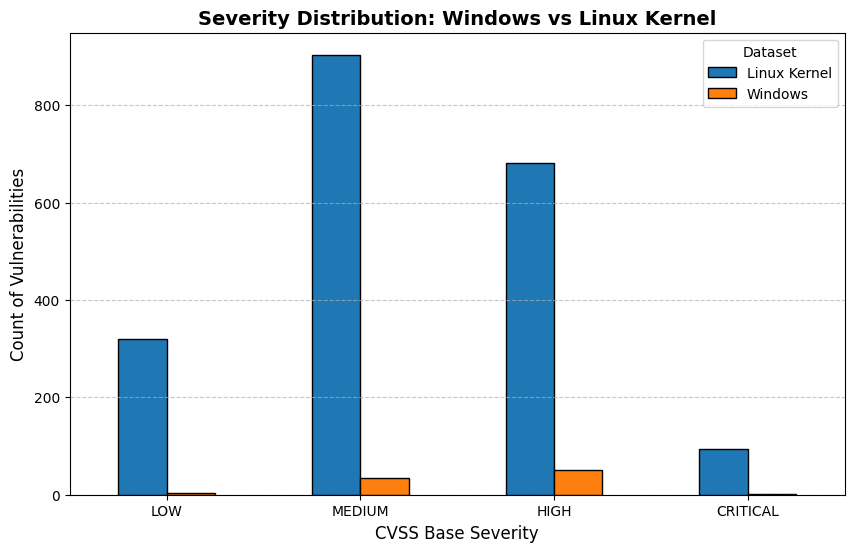


--- Top 5 Vulnerability Types (CWE) ---

Windows:
Vulnerability_Type
CWE-787    39
CWE-200    18
CWE-665     5
CWE-125     3
CWE-20      3
Name: count, dtype: int64

Linux Kernel:
Vulnerability_Type
CWE-119    238
CWE-20     175
CWE-200    174
CWE-399    147
CWE-264    135
Name: count, dtype: int64


In [10]:
# Compare the two datasets with Pandas
# Add a "Dataset" column to distinguish them
df['Dataset'] = 'Windows'
df_linux['Dataset'] = 'Linux Kernel'

# Combine the dataframes
combined_df = pd.concat([df, df_linux], ignore_index=True)

# 1. Compare average CVSS Score
avg_scores = combined_df.groupby('Dataset')['CVSS_Score'].mean()
print("--- Average CVSS Score ---")
print(avg_scores)

# 2. Compare Severity distribution
import matplotlib.pyplot as plt

valid_df = combined_df[combined_df['Severity'] != 'NONE']
severity_counts = valid_df.groupby(['Severity', 'Dataset']).size().unstack(fill_value=0)

order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
existing_order = [s for s in order if s in severity_counts.index]
severity_counts = severity_counts.loc[existing_order]

severity_counts.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('Severity Distribution: Windows vs Linux Kernel', fontsize=14, fontweight='bold')
plt.xlabel('CVSS Base Severity', fontsize=12)
plt.ylabel('Count of Vulnerabilities', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Compare top 5 Vulnerability Types for each
print("\n--- Top 5 Vulnerability Types (CWE) ---")
print("\nWindows:")
print(df[~df['Vulnerability_Type'].isin(['Unknown', 'NVD-CWE-noinfo', 'NVD-CWE-Other'])]['Vulnerability_Type'].value_counts().head(5))
print("\nLinux Kernel:")
print(df_linux[~df_linux['Vulnerability_Type'].isin(['Unknown', 'NVD-CWE-noinfo', 'NVD-CWE-Other'])]['Vulnerability_Type'].value_counts().head(5))


### Linux Kernel Vulnerabilities Over Time
Here is the scatter plot visualizing the Linux Kernel dataset chronological timeline.

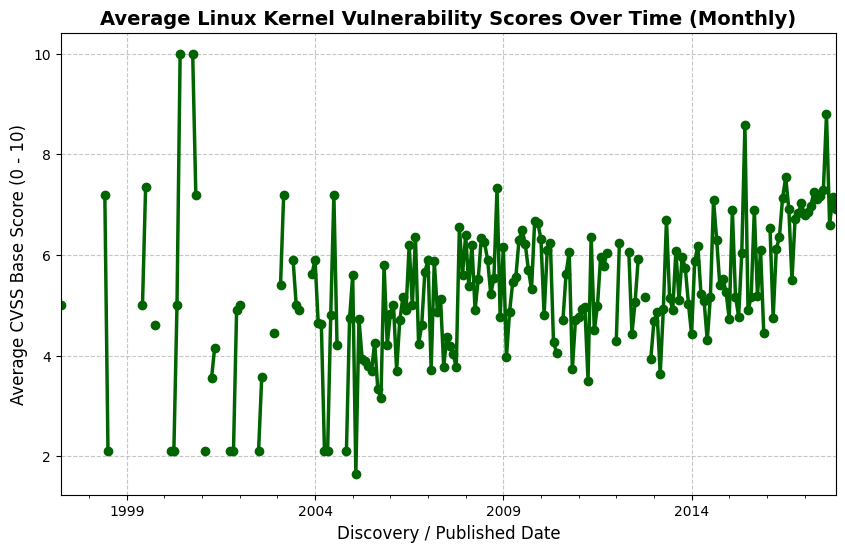

In [11]:
scatter_df_linux = df_linux.dropna(subset=['Published_Date', 'CVSS_Score'])

if not scatter_df_linux.empty:
    # Set date as index and group by month to get the average score over time
    monthly_avg = scatter_df_linux.set_index('Published_Date').resample('ME')['CVSS_Score'].mean()
    
    ax = monthly_avg.plot(
        kind='line', 
        color='darkgreen', 
        figsize=(10, 6),
        linewidth=2.5,
        marker='o'
    )
    
    plt.title('Average Linux Kernel Vulnerability Scores Over Time (Monthly)', fontsize=14, fontweight='bold')
    plt.xlabel('Discovery / Published Date', fontsize=12)
    plt.ylabel('Average CVSS Base Score (0 - 10)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.show()
else:
    print("Not enough data to plot.")